In [1]:
# Import all necessary deep learning, data, and visualization libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, transforms, models
import os
import time
import copy
import numpy as np
from collections import Counter
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Set device to GPU if available, otherwise use CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [2]:
!pip install split-folders

In [3]:
# Constants for Transfer Learning
IMAGENET_MEAN = [0.485, 0.456, 0.406] # Mean for ImageNet normalization
IMAGENET_STD = [0.229, 0.224, 0.225]   # Standard Deviation for ImageNet normalization
IMAGE_SIZE = 224                      # Standard size expected by ResNet
BATCH_SIZE = 32
NUM_EPOCHS = 60                       # Sufficient epochs for fine-tuning the head | 30 => 0.86
LEARNING_RATE = 0.001

In [4]:
# Transform for training data (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transform for validation data (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Transforms defined with ImageNet normalization.")

Transforms defined with ImageNet normalization.


In [5]:
# Cell 4: Data Splitting (CRUCIAL STEP)

!pip install splitfolders
import splitfolders

# Define the input directory where all your class folders are located
# Assuming your main folder containing all 6 class sub-folders is named 'DataSet'
input_dir = "/kaggle/input/solar-pannel-noise-removal/solar panel classes - noise removed"

# Define the output directory where the 'train', 'val' folders will be created
output_dir = "/content/DataSet_Split"

# Define the split ratio (e.g., 80% train, 20% validation)
# If you have a separate test set, you would use ratio=(0.7, 0.2, 0.1)
split_ratio = (0.8, 0.2)

# Perform the split
print("Starting dataset split...")
splitfolders.ratio(
    input_dir, 
    output=output_dir, 
    seed=42, 
    ratio=split_ratio, 
    group_prefix=None, 
    move=False
)
print("Dataset split complete. Folders created in: /content/DataSet_Split")

ERROR: Could not find a version that satisfies the requirement splitfolders (from versions: none)
ERROR: No matching distribution found for splitfolders
Starting dataset split...


Copying files: 840 files [00:06, 137.46 files/s]

Dataset split complete. Folders created in: /content/DataSet_Split


In [6]:
# Paths to your split dataset folders
data_dir = '/content/DataSet_Split'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')

# Create the datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)

# Determine the number of classes automatically
NUM_CLASSES = len(train_dataset.classes)
print(f"Detected {NUM_CLASSES} classes: {train_dataset.classes}")
print(f"Training images: {len(train_dataset)}, Validation images: {len(val_dataset)}")

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)
dataloaders = {'train': train_loader, 'val': val_loader}

Detected 6 classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
Training images: 664, Validation images: 170


In [7]:
# Cell 6: Transfer Learning Model Setup (ConvNeXt Tiny)

# Load pre-trained ConvNeXt Tiny model
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

# Freeze all the body parameters (Feature Preservation)
for param in model.parameters():
    param.requires_grad = False

# The ConvNeXt classification head is in `model.classifier`.
# The final linear layer is typically at index 2: model.classifier[2].
num_ftrs = model.classifier[2].in_features

# Replace the final layer for our NUM_CLASSES (Task Adaptation)
model.classifier[2] = nn.Linear(num_ftrs, NUM_CLASSES)

# Move the model to the correct device
model = model.to(device)

print(f"ConvNeXt Tiny body frozen. New classification head has {NUM_CLASSES} outputs.")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 211MB/s] 


ConvNeXt Tiny body frozen. New classification head has 6 outputs.


In [8]:
# Calculate Class Weights to handle imbalance
class_counts = Counter(train_dataset.targets)
sorted_counts = [count for _, count in sorted(class_counts.items())]
total_samples = sum(sorted_counts)

# Weights = Total_Samples / (Num_Classes * Count_i)
class_weights = total_samples / (NUM_CLASSES * np.array(sorted_counts))
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"Class Frequencies (Sorted): {sorted_counts}")
print(f"Class Weights (Higher weight = rarer class): {class_weights_tensor.tolist()}")

# Define the Weighted Cross-Entropy Loss
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

Class Frequencies (Sorted): [143, 147, 144, 78, 54, 98]
Class Weights (Higher weight = rarer class): [0.7738927602767944, 0.7528344392776489, 0.7685185074806213, 1.4188034534454346, 2.0493826866149902, 1.1292517185211182]


In [10]:
# Optimizer: Only train the final layer parameters (requires_grad=True)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=LEARNING_RATE
)

# Scheduler: Reduce LR when validation loss plateaus (patience=5 epochs)
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.1, 
    patience=5,
    # verbose=True
)

print("Optimizer and scheduler configured.")

Optimizer and scheduler configured.


In [11]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Training mode
            else:
                model.eval()   # Evaluation mode

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase], desc=f'{phase} phase'):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)

            # Save the best model based on validation accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [12]:
# Execute the training function
model_ft = train_model(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS)

Epoch 0/59
----------


train phase: 100%|██████████| 21/21 [00:12<00:00,  1.75it/s]


train Loss: 1.5422 Acc: 0.4352


val phase: 100%|██████████| 6/6 [00:04<00:00,  1.24it/s]


val Loss: 1.3360 Acc: 0.4882

Epoch 1/59
----------


...

val Loss: 0.3452 Acc: 0.9059

Epoch 59/59
----------


train phase: 100%|██████████| 21/21 [00:08<00:00,  2.54it/s]


train Loss: 0.1980 Acc: 0.9307


val phase: 100%|██████████| 6/6 [00:03<00:00,  1.97it/s]

val Loss: 0.3592 Acc: 0.9059

Training complete in 11m 33s
Best val Acc: 0.9176


Evaluating: 100%|██████████| 6/6 [00:03<00:00,  1.99it/s]


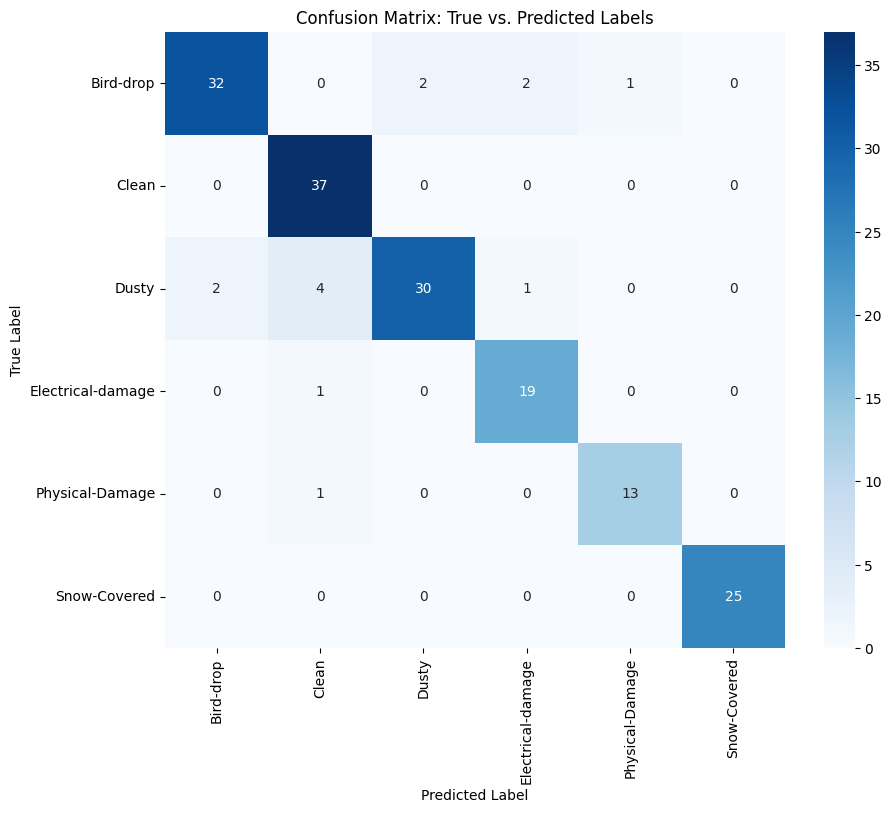


--- Detailed Classification Report ---

                   precision    recall  f1-score   support

        Bird-drop     0.9412    0.8649    0.9014        37
            Clean     0.8605    1.0000    0.9250        37
            Dusty     0.9375    0.8108    0.8696        37
Electrical-damage     0.8636    0.9500    0.9048        20
  Physical-Damage     0.9286    0.9286    0.9286        14
     Snow-Covered     1.0000    1.0000    1.0000        25

         accuracy                         0.9176       170
        macro avg     0.9219    0.9257    0.9216       170
     weighted avg     0.9213    0.9176    0.9167       170



In [14]:
def evaluate_model(model, dataloader, class_names):
    """Generates predictions, confusion matrix, and classification report."""
    
    model.eval() # Set model to evaluation mode
    all_preds = []
    all_labels = []

    # Disable gradient calculations for inference
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluating'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- 1. Confusion Matrix ---
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=class_names, 
        yticklabels=class_names
    )
    plt.title('Confusion Matrix: True vs. Predicted Labels')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # --- 2. Classification Report ---
    report = classification_report(
        all_labels, 
        all_preds, 
        target_names=class_names, 
        digits=4
    )
    print("\n--- Detailed Classification Report ---\n")
    print(report)

# Execute the final evaluation on the validation set
class_names = val_dataset.classes
evaluate_model(model_ft, val_loader, class_names)